# **Классификация грибов.**
Разберем небольшую задача с предсказанием ядовитый гриб или сьедобный.

About this file

Suggest Edits
Attribute Information: (classes: edible=e, poisonous=p)

cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

bruises: bruises=t,no=f

odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

gill-attachment: attached=a,descending=d,free=f,notched=n

gill-spacing: close=c,crowded=w,distant=d

gill-size: broad=b,narrow=n

gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

stalk-shape: enlarging=e,tapering=t

stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

veil-type: partial=p,universal=u

veil-color: brown=n,orange=o,white=w,yellow=y

ring-number: none=n,one=o,two=t

ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from matplotlib import pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv('./mushrooms.csv')

In [13]:
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [15]:
data['class'] = data['class'].replace({'e': 1, 'p': 0})


/tmp/ipykernel_1991/137084479.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['class'] = data['class'].replace({'e': 1, 'p': 0})


Посмотрим на распределние целевой переменной

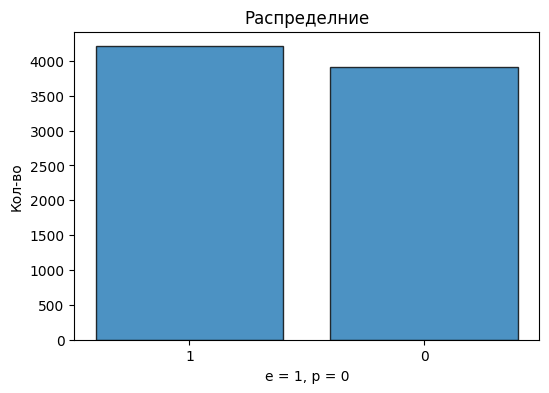

In [20]:
counts = data['class'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values, edgecolor='black', alpha=0.8)
plt.title('Распределние')
plt.xlabel('e = 1, p = 0')
plt.ylabel('Кол-во')
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [32]:
X = data.drop(columns=['class'])
y = data['class']

cat_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=72
)

encoder = OneHotEncoder(drop='first')
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

model = LogisticRegression(random_state=72)
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9993846153846154


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])


param_grid = {'classifier__C': [100, 10, 1, 0.1, 0.01, 0.001]}
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, refit=True
)
grid_search.fit(X_train, y_train)

print("Лучший параметр C:", grid_search.best_params_['classifier__C'])

Лучший параметр C: 100


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


In [40]:
best_model = grid_search.best_estimator_
y_val_pred_proba = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9993846153846154


In [45]:
# !pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [48]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    cat_features=cat_cols.to_list(),
    random_state=72,
    verbose=False
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy =', accuracy_score(y_test, y_pred))

Accuracy = 1.0


Вообще, здесь надо использовать явно не метрику accuracy, а то сьешь не тот гриб и все... (Но мы добились точности 1 так что можно этого и не проверять)

In [50]:
from sklearn.metrics import f1_score, precision_score, recall_score


prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1: {f1:.4f}')

Precision: 1.0000
Recall: 1.0000
F1: 1.0000


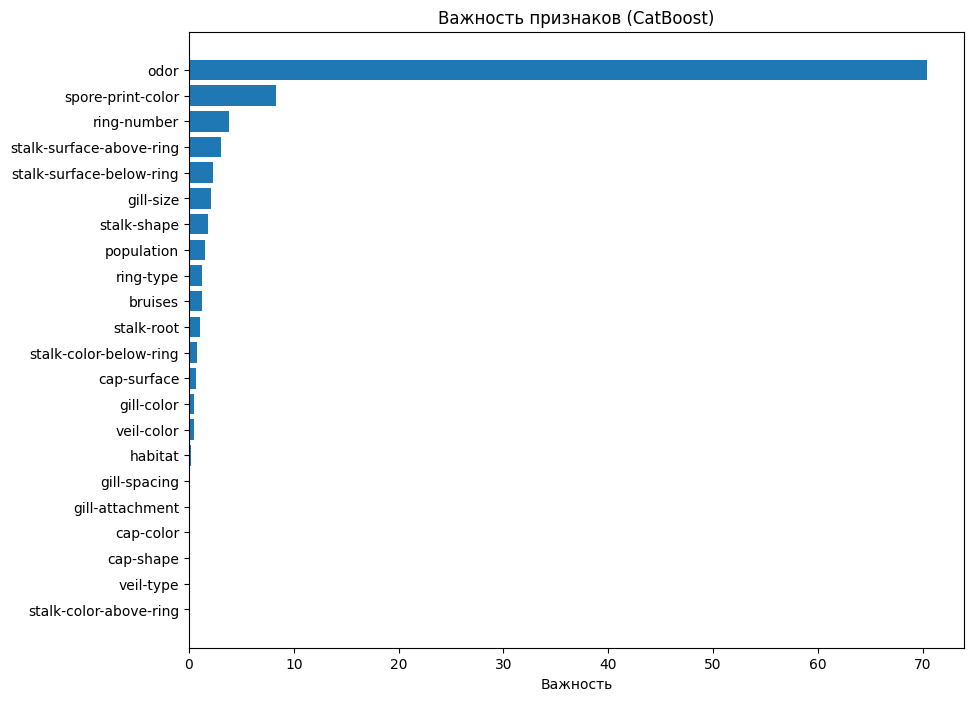

In [55]:
feature_importances = model.get_feature_importance()
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), [cat_cols[i] for i in sorted_idx])
plt.gca().invert_yaxis()
plt.title('Важность признаков')
plt.xlabel('Важность')
plt.show()

Удалим неважные признаки, оставим самые значимые

In [59]:
model_cat = CatBoostClassifier(
    cat_features=cat_cols.tolist(),
    random_state=72,
    verbose=False
)
model_cat.fit(X_train, y_train)

feature_importances = model_cat.get_feature_importance()
importance_df = pd.DataFrame({
    'feature': cat_cols,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

top_k = 5
important_features = importance_df.head(top_k)['feature'].tolist()

print("Выбранные признаки:", important_features)

Выбранные признаки: ['odor', 'spore-print-color', 'ring-number', 'stalk-surface-above-ring', 'stalk-surface-below-ring']


In [60]:
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]

model_cat_imp = CatBoostClassifier(
    cat_features=important_features,
    random_state=72,
    verbose=False
)

model_cat_imp.fit(X_train_imp, y_train)
y_pred_imp = model_cat_imp.predict(X_test_imp)
print("Accuracy после отбора:", accuracy_score(y_test, y_pred_imp))

Accuracy после отбора: 0.9981538461538462
